# Midterm Project: Comparative Analysis of Supervised and Unsupervised Learning
## Car Price Prediction Dataset
**Tools:** Python | pandas | numpy | matplotlib | seaborn | scikit-learn  
**Dataset:** Vehicle Dataset from CarDekho (Kaggle)  
**Kaggle Link:** https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho

## PART A: DATA PREPARATION (20 points)

Tasks:
1. Download dataset from Kaggle (via Kaggle API)
2. Load dataset using pandas
3. Clean data (missing values, duplicates)
4. Feature selection
5. Encode categorical variables
6. Feature scaling

In [1]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    'nehalbirla/vehicle-dataset-from-cardekho',
    'Car details v3.csv',
)
print('Dataset shape:', df.shape)
df.head()

Using Colab cache for faster access to the 'vehicle-dataset-from-cardekho' dataset.
Dataset shape: (8128, 13)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [3]:
print('Dataset Shape:', df.shape)
print('\nColumn Info:')
print(df.dtypes)

Dataset Shape: (8128, 13)

Column Info:
name              object
year               int64
selling_price      int64
km_driven          int64
fuel              object
seller_type       object
transmission      object
owner             object
mileage           object
engine            object
max_power         object
torque            object
seats            float64
dtype: object


In [4]:
# Check missing values
print('Missing Values Per Column:')
print(df.isnull().sum())
print('\nBasic Statistics:')
df.describe(include='all').T

Missing Values Per Column:
name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64

Basic Statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
name,8128,2058,Maruti Swift Dzire VDI,129,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,8128.0,NaN,NaN,NaN,2013.804011,4.044249,1983.0,2011.0,2015.0,2017.0,2020.0
selling_price,8128.0,NaN,NaN,NaN,638271.807702,806253.403508,29999.0,254999.0,450000.0,675000.0,10000000.0
km_driven,8128.0,NaN,NaN,NaN,69819.510827,56550.554958,1.0,35000.0,60000.0,98000.0,2360457.0
fuel,8128,4,Diesel,4402,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seller_type,8128,3,Individual,6766,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transmission,8128,2,Manual,7078,NaN,NaN,NaN,NaN,NaN,NaN,NaN
owner,8128,5,First Owner,5289,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mileage,7907,393,18.9 kmpl,225,NaN,NaN,NaN,NaN,NaN,NaN,NaN
engine,7907,121,1248 CC,1017,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 2. Data Cleaning

In [5]:
def to_float(val):
    if pd.isna(val):
        return np.nan
    m = re.search(r'[-+]?\d*\.?\d+', str(val))
    return float(m.group()) if m else np.nan

for col in ['mileage', 'engine', 'max_power']:
    df[col] = df[col].apply(to_float)

if 'torque' in df.columns:
    df = df.drop(columns=['torque'])

df[['mileage', 'engine', 'max_power']].head()

,mileage,engine,max_power
0,23.40,1248.0,74.00
1,21.14,1498.0,103.52
2,17.70,1497.0,78.00
3,23.00,1396.0,90.00
4,16.10,1298.0,88.20


In [6]:
# Drop duplicates
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f'Duplicates removed: {before - len(df)}')

# Impute null values (NaNs) with median
for col in ['mileage', 'engine', 'max_power', 'seats']:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"Filled '{col}' with median: {median_val:.2f}")

print(f'\nMissing values remaining: {df.isnull().sum().sum()}')
print('Shape after cleaning:', df.shape)

Duplicates removed: 1202
Filled 'mileage' with median: 19.44
Filled 'engine' with median: 1248.00
Filled 'max_power' with median: 81.83
Filled 'seats' with median: 5.00

Missing values remaining: 0
Shape after cleaning: (6926, 12)


### 3. Feature Engineering & Encoding

In [7]:
# Feature engineering: car age
df['car_age'] = 2024 - df['year']

# Encode categorical columns
le = LabelEncoder()
cat_cols = ['name', 'fuel', 'seller_type', 'transmission', 'owner']
for col in cat_cols:
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))

print("New encoded columns:", [c for c in df.columns if c.endswith('_enc')])
print("\nFinal cleaned dataset shape:", df.shape)

# Save cleaned dataset
df.to_csv('car_price_cleaned.csv', index=False)
print("Cleaned dataset saved as 'car_price_cleaned.csv'")


New encoded columns: ['name_enc', 'fuel_enc', 'seller_type_enc', 'transmission_enc', 'owner_enc']

Final cleaned dataset shape: (6926, 18)
Cleaned dataset saved as 'car_price_cleaned.csv'


In [8]:
# Feature engineering: car_age is more meaningful than raw year for price
df['car_age'] = 2024 - df['year']

# Encode categorical variables with LabelEncoder
cat_cols = ['fuel', 'seller_type', 'transmission', 'owner']
for col in cat_cols:
    df[col + '_enc'] = LabelEncoder().fit_transform(df[col].astype(str))

# Feature selection: drop high-cardinality 'name' and the raw categorical cols,
# keep numerical + encoded features for modeling.
feature_cols = [
    'car_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats',
    'fuel_enc', 'seller_type_enc', 'transmission_enc', 'owner_enc'
]
target_col = 'selling_price'

X = df[feature_cols].copy()
y = df[target_col].copy()

print('Selected features:', feature_cols)
print('Target:', target_col)
print('X shape:', X.shape, '| y shape:', y.shape)

Selected features: ['car_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'fuel_enc', 'seller_type_enc', 'transmission_enc', 'owner_enc']
Target: selling_price
X shape: (6926, 10) | y shape: (6926,)


In [9]:
# Feature scaling (StandardScaler) — helpful for Linear Regression and required for K-Means in Part C
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_cols)
X_scaled.describe().T[['mean', 'std', 'min', 'max']]

,mean,std,min,max
car_age,3.077719e-17,1.000072,-1.613466,7.459627
km_driven,-8.617613e-17,1.000072,-1.268033,39.182677
mileage,-8.002070e-17,1.000072,-4.881281,5.651396
engine,6.770982e-17,1.000072,-1.645610,4.473589
max_power,-1.949222e-17,1.000072,-2.796346,9.979426
seats,2.256994e-17,1.000072,-3.519800,8.824601
fuel_enc,-1.744041e-16,1.000072,-1.880529,1.110869
seller_type_enc,-1.128497e-16,1.000072,-2.964601,3.582856
transmission_enc,1.600414e-16,1.000072,-3.295389,0.303454
owner_enc,-5.334713e-17,1.000072,-0.719060,2.455070


In [10]:
# Save cleaned dataset
cleaned = pd.concat([X, y], axis=1)
cleaned.to_csv('car_price_cleaned.csv', index=False)
print('Cleaned dataset saved as car_price_cleaned.csv')
cleaned.head()

Cleaned dataset saved as car_price_cleaned.csv


,car_age,km_driven,mileage,engine,max_power,seats,fuel_enc,seller_type_enc,transmission_enc,owner_enc,selling_price
0,10,145500,23.40,1248.0,74.00,5.0,1,1,1,0,450000
1,10,120000,21.14,1498.0,103.52,5.0,1,1,1,2,370000
2,18,140000,17.70,1497.0,78.00,5.0,3,1,1,4,158000
3,14,127000,23.00,1396.0,90.00,5.0,1,1,1,0,225000
4,17,120000,16.10,1298.0,88.20,5.0,3,1,1,0,130000


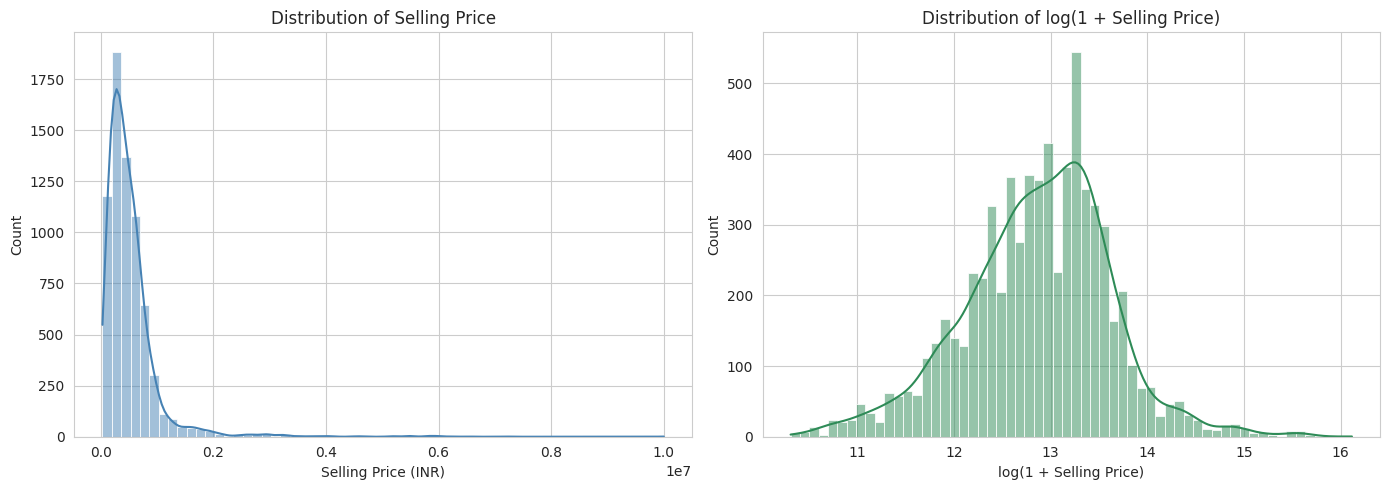

Skewness (raw)  : 5.573
Skewness (log1p): -0.157


In [11]:
# Distribution of the target variable (selling_price)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(y, bins=60, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Distribution of Selling Price')
axes[0].set_xlabel('Selling Price (INR)')
axes[0].set_ylabel('Count')

sns.histplot(np.log1p(y), bins=60, kde=True, color='seagreen', ax=axes[1])
axes[1].set_title('Distribution of log(1 + Selling Price)')
axes[1].set_xlabel('log(1 + Selling Price)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f'Skewness (raw)  : {y.skew():.3f}')
print(f'Skewness (log1p): {np.log1p(y).skew():.3f}')

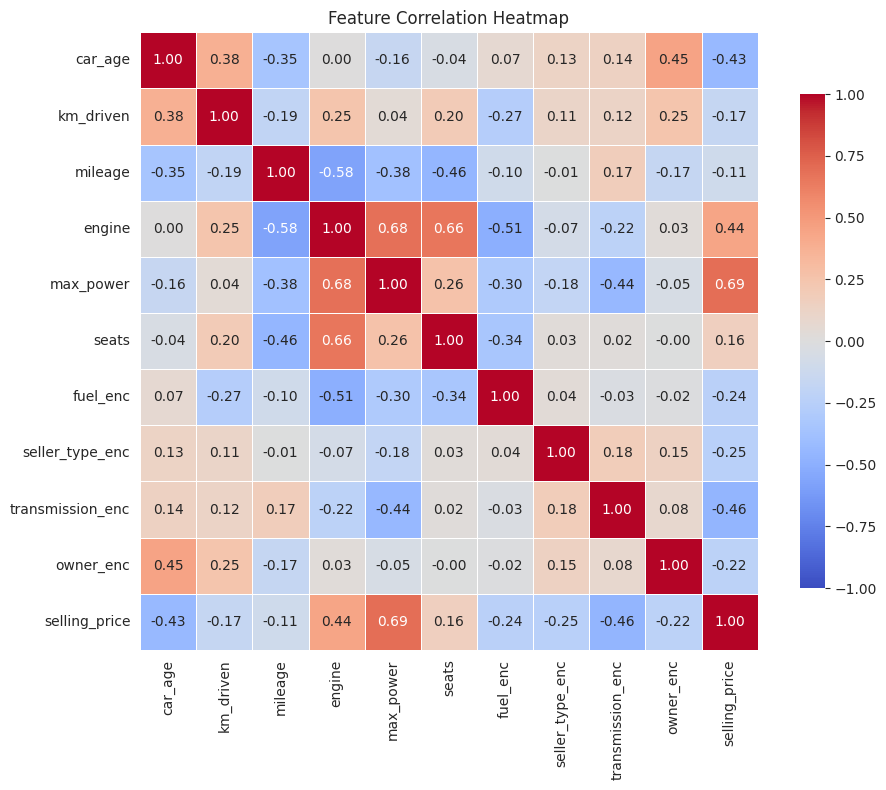

Correlation with selling_price:
max_power           0.688838
transmission_enc   -0.462683
engine              0.444760
car_age            -0.433076
seller_type_enc    -0.248659
fuel_enc           -0.241328
owner_enc          -0.224121
km_driven          -0.165620
seats               0.163942
mileage            -0.107372
Name: selling_price, dtype: float64


In [12]:
# Feature Correlation Heatmap (features + target)
corr = pd.concat([X, y], axis=1).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# Correlations with the target, sorted
print('Correlation with selling_price:')
print(corr['selling_price'].drop('selling_price').sort_values(key=abs, ascending=False))

### Data Description

- Source: Kaggle — *Vehicle Dataset from CarDekho* (`Car details v3.csv`), ~8k used-car listings from India.
- Target variable: `selling_price` (INR) — continuous numerical, suitable for regression.
- Numerical features used: `car_age` (derived from `year`), `km_driven`, `mileage` (kmpl), `engine` (cc), `max_power` (bhp), `seats`.
- Categorical features (label-encoded): `fuel`, `seller_type`, `transmission`, `owner`.
- Cleaning: unit strings in `mileage`/`engine`/`max_power` parsed to floats, `torque` dropped (messy, redundant with `max_power`), duplicates removed, missing numerical values imputed with column medians.
- Scaling: `StandardScaler` applied to all ten features for use by Linear Regression and K-Means.

## PART B: SUPERVISED LEARNING — REGRESSION (30 points)

Tasks:
1. Train/test split (80/20)
2. Train Linear Regression (required) and Random Forest Regressor (optional)
3. Evaluate with MAE, MSE, R²
4. Plot Prediction vs Actua

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
print('Train size:', X_train.shape, '| Test size:', X_test.shape)

Train size: (5540, 10) | Test size: (1386, 10)


In [14]:
# Linear Regression (minimum requirement)
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
y_pred_lin = lin_model.predict(X_test)

mae_lin = mean_absolute_error(y_test, y_pred_lin)
mse_lin = mean_squared_error(y_test, y_pred_lin)
r2_lin  = r2_score(y_test, y_pred_lin)

print('=== Linear Regression ===')
print(f'MAE : {mae_lin:,.2f}')
print(f'MSE : {mse_lin:,.2f}')
print(f'RMSE: {np.sqrt(mse_lin):,.2f}')
print(f'R^2 : {r2_lin:.4f}')

=== Linear Regression ===
MAE : 173,245.83
MSE : 94,596,219,903.38
RMSE: 307,564.98
R^2 : 0.5687


,feature,coefficient
4,max_power,268635.640157
0,car_age,-129357.459022
8,transmission_enc,-90649.320031
1,km_driven,-58499.783689
7,seller_type_enc,-39482.780558
6,fuel_enc,-38289.052934
3,engine,34222.224387
9,owner_enc,-14990.767879
2,mileage,13221.027303
5,seats,-7363.948151


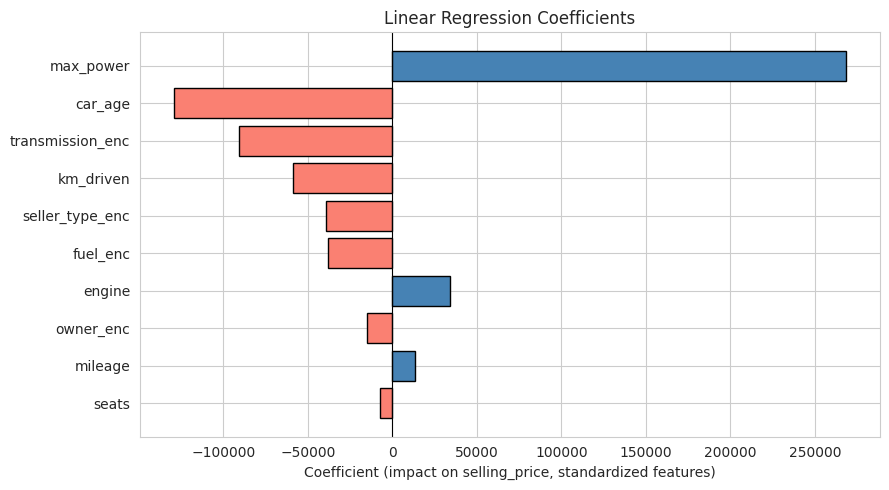

In [15]:
# Linear regression coefficients (on standardized features)
coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': lin_model.coef_
}).sort_values('coefficient', key=abs, ascending=False)

display(coef_df)

# Visualize as a horizontal bar chart
plt.figure(figsize=(9, 5))
colors = ['steelblue' if v > 0 else 'salmon' for v in coef_df['coefficient']]
plt.barh(coef_df['feature'], coef_df['coefficient'], color=colors, edgecolor='k')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coefficient (impact on selling_price, standardized features)')
plt.title('Linear Regression Coefficients')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [16]:
# Random Forest Regressor (optional, often much stronger on tabular data)
rf_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf  = r2_score(y_test, y_pred_rf)

print('=== Random Forest Regressor ===')
print(f'MAE : {mae_rf:,.2f}')
print(f'MSE : {mse_rf:,.2f}')
print(f'RMSE: {np.sqrt(mse_rf):,.2f}')
print(f'R^2 : {r2_rf:.4f}')

=== Random Forest Regressor ===
MAE : 75,373.83
MSE : 17,666,725,270.68
RMSE: 132,916.23
R^2 : 0.9194


In [17]:
metrics = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE':   [mae_lin, mae_rf],
    'MSE':   [mse_lin, mse_rf],
    'RMSE':  [np.sqrt(mse_lin), np.sqrt(mse_rf)],
    'R^2':   [r2_lin, r2_rf],
})
metrics

,Model,MAE,MSE,RMSE,R^2
0,Linear Regression,173245.834519,9.459622e+10,307564.984846,0.568687
1,Random Forest,75373.827143,1.766673e+10,132916.234037,0.919448


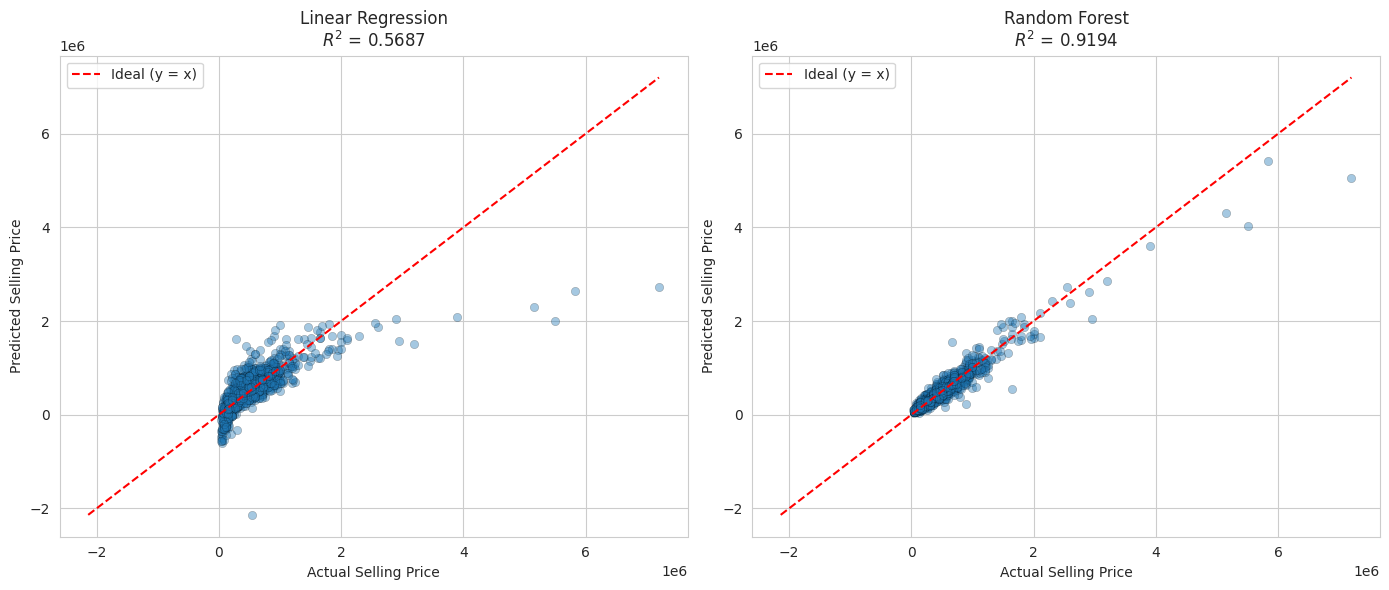

In [18]:
# Prediction vs Actual graph for both models
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
lims = [min(y_test.min(), y_pred_lin.min(), y_pred_rf.min()),
        max(y_test.max(), y_pred_lin.max(), y_pred_rf.max())]

for ax, y_pred, title, r2 in [
    (axes[0], y_pred_lin, 'Linear Regression', r2_lin),
    (axes[1], y_pred_rf,  'Random Forest',     r2_rf),
]:
    ax.scatter(y_test, y_pred, alpha=0.4, edgecolor='k', linewidth=0.3)
    ax.plot(lims, lims, 'r--', label='Ideal (y = x)')
    ax.set_xlabel('Actual Selling Price')
    ax.set_ylabel('Predicted Selling Price')
    ax.set_title(f'{title}\n$R^2$ = {r2:.4f}')
    ax.legend()

plt.tight_layout()
plt.show()

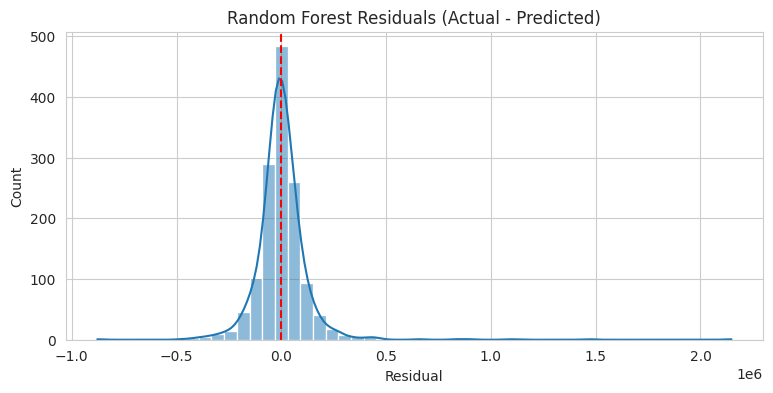

In [19]:
# Residual distribution for the stronger model
residuals = y_test - y_pred_rf
plt.figure(figsize=(9, 4))
sns.histplot(residuals, bins=50, kde=True)
plt.axvline(0, color='r', linestyle='--')
plt.title('Random Forest Residuals (Actual - Predicted)')
plt.xlabel('Residual')
plt.show()

## Part C: Unsupervised Learning – K-Means Clustering (30 pts)

### Task 1 & 2: Feature Selection & Standardization

We reuse `X_scaled` (already standardized in Part A) and select only numerical features, excluding the target variable `selling_price`.

In [20]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Task 1: Feature selection — reuse X_scaled from Part A (no target variable)
# X_scaled already contains: car_age, km_driven, mileage, engine,
#                             max_power, seats, fuel_enc, seller_type_enc,
#                             transmission_enc, owner_enc
print('Features used for clustering:')
print(feature_cols)
print(f'\nShape of scaled feature matrix: {X_scaled.shape}')

# Task 2: Features are already standardized (StandardScaler applied in Part A)
print('\nFeature scaling: already applied via StandardScaler in Part A')
print(X_scaled.describe().T[['mean', 'std']].round(4))

Features used for clustering:
['car_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'fuel_enc', 'seller_type_enc', 'transmission_enc', 'owner_enc']

Shape of scaled feature matrix: (6926, 10)

Feature scaling: already applied via StandardScaler in Part A
                  mean     std
car_age            0.0  1.0001
km_driven         -0.0  1.0001
mileage           -0.0  1.0001
engine             0.0  1.0001
max_power         -0.0  1.0001
seats              0.0  1.0001
fuel_enc          -0.0  1.0001
seller_type_enc   -0.0  1.0001
transmission_enc   0.0  1.0001
owner_enc         -0.0  1.0001


### Task 3 & 4: Apply K-Means & Determine Optimal k (Elbow Method)




  k=2  |  Inertia:         54,217  |  Silhouette: 0.3384
  k=3  |  Inertia:         46,732  |  Silhouette: 0.1983
  k=4  |  Inertia:         40,629  |  Silhouette: 0.2256
  k=5  |  Inertia:         35,608  |  Silhouette: 0.2421
  k=6  |  Inertia:         31,779  |  Silhouette: 0.2638
  k=7  |  Inertia:         29,522  |  Silhouette: 0.2758
  k=8  |  Inertia:         27,502  |  Silhouette: 0.2735
  k=9  |  Inertia:         26,571  |  Silhouette: 0.2777
  k=10  |  Inertia:         24,342  |  Silhouette: 0.2636


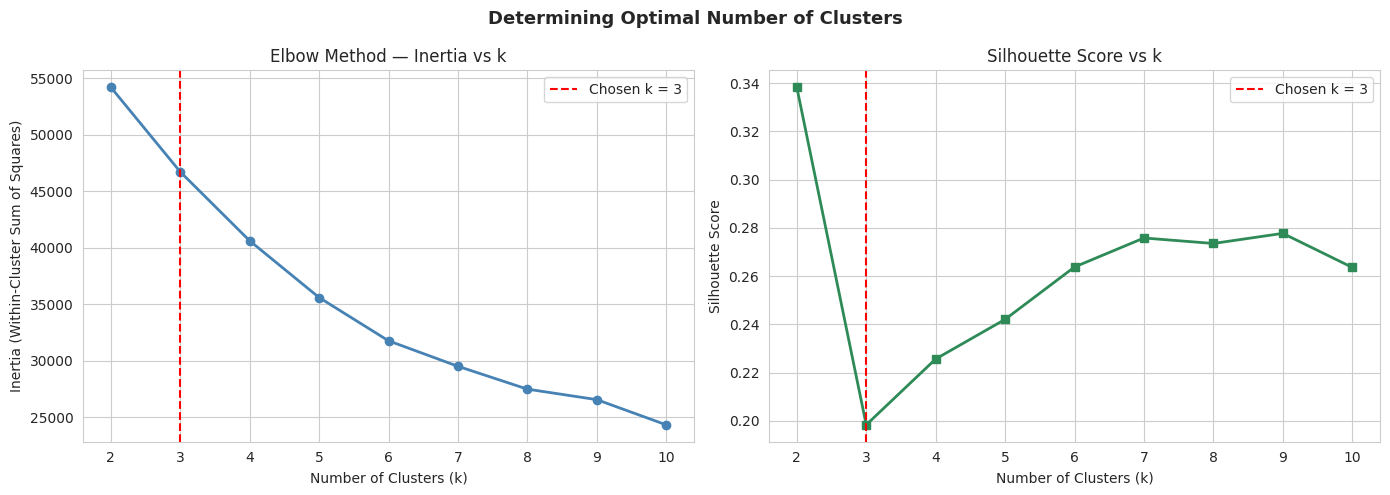

In [21]:
# Elbow Method + Silhouette Score to determine optimal k
inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, km.labels_)
    silhouette_scores.append(sil)
    print(f'  k={k}  |  Inertia: {km.inertia_:>14,.0f}  |  Silhouette: {sil:.4f}')

# ── Elbow Plot ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertias, marker='o', color='steelblue', linewidth=2)
axes[0].axvline(x=3, color='red', linestyle='--', label='Chosen k = 3')
axes[0].set_title('Elbow Method — Inertia vs k')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)')
axes[0].legend()

axes[1].plot(list(k_range), silhouette_scores, marker='s', color='seagreen', linewidth=2)
axes[1].axvline(x=3, color='red', linestyle='--', label='Chosen k = 3')
axes[1].set_title('Silhouette Score vs k')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()

plt.suptitle('Determining Optimal Number of Clusters', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [22]:
# Fit final K-Means with k = 3 (elbow + silhouette both support this)
OPTIMAL_K = 3
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

print(f'K-Means fitted with k = {OPTIMAL_K}')
print(f'Final Inertia    : {kmeans.inertia_:,.2f}')
print(f'Final Silhouette : {silhouette_score(X_scaled, cluster_labels):.4f}')

print('\nCluster distribution:')
unique, counts = np.unique(cluster_labels, return_counts=True)
for c, n in zip(unique, counts):
    print(f'  Cluster {c}: {n:,} cars  ({n/len(cluster_labels)*100:.1f}%)')

# Add cluster labels to the dataframe
df['cluster'] = cluster_labels
print('\nCluster column added to df.')

K-Means fitted with k = 3
Final Inertia    : 46,731.79
Final Silhouette : 0.1983

Cluster distribution:
  Cluster 0: 1,280 cars  (18.5%)
  Cluster 1: 3,583 cars  (51.7%)
  Cluster 2: 2,063 cars  (29.8%)

Cluster column added to df.


### Task 5: Cluster Visualization

PCA explained variance: PC1=0.289, PC2=0.200  (total=0.489)


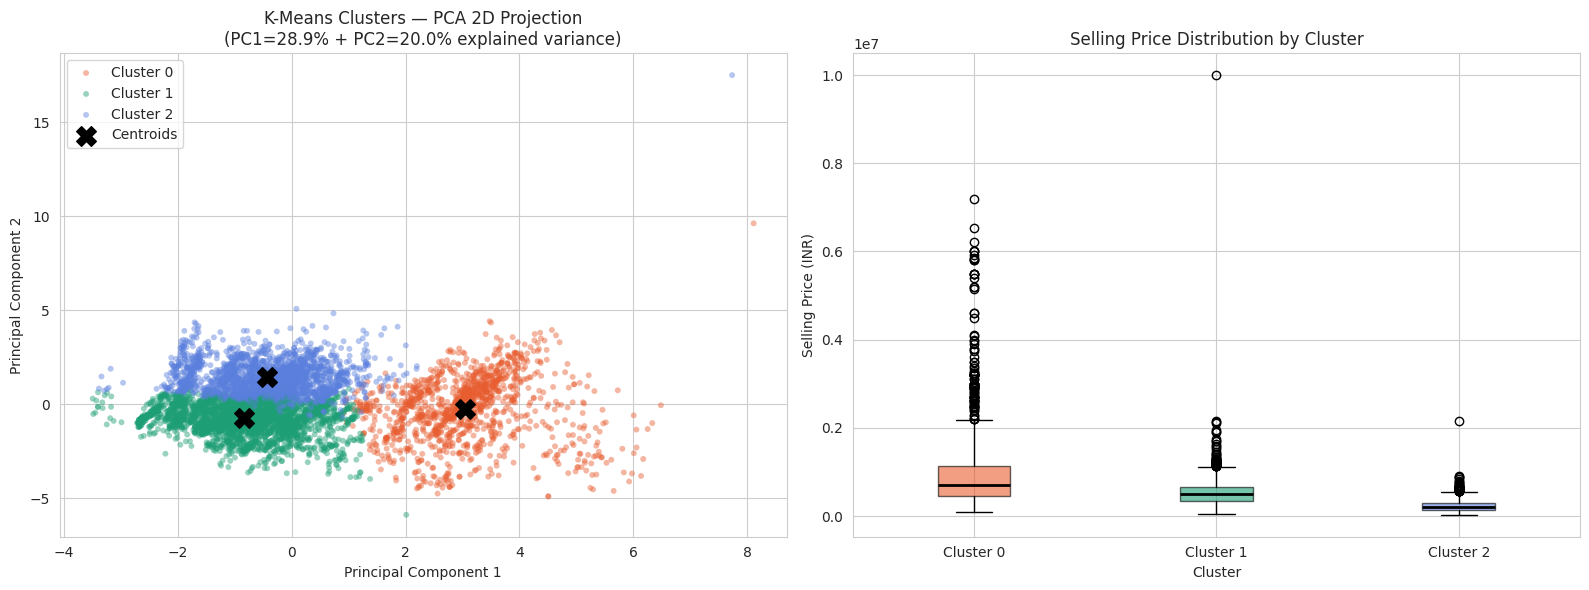

In [23]:
# PCA — reduce to 2D for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_
print(f'PCA explained variance: PC1={explained[0]:.3f}, PC2={explained[1]:.3f}  '
      f'(total={sum(explained):.3f})')

palette = ['#E85D30', '#1D9E75', '#5A7FDD']
cluster_names = ['Cluster 0', 'Cluster 1', 'Cluster 2']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# — Left: PCA Scatter Plot —
for i, (name, color) in enumerate(zip(cluster_names, palette)):
    mask = cluster_labels == i
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=color, label=name, alpha=0.45, edgecolors='none', s=18)

centroids_pca = pca.transform(kmeans.cluster_centers_)
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1],
                c='black', marker='X', s=200, zorder=5, label='Centroids')
axes[0].set_title(f'K-Means Clusters — PCA 2D Projection\n'
                  f'(PC1={explained[0]:.1%} + PC2={explained[1]:.1%} explained variance)')
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')
axes[0].legend()

# — Right: Selling Price by Cluster (Box Plot) —
cluster_price_data = [df.loc[df['cluster'] == i, 'selling_price'].values
                       for i in range(OPTIMAL_K)]
bp = axes[1].boxplot(cluster_price_data, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[1].set_title('Selling Price Distribution by Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Selling Price (INR)')
axes[1].set_xticklabels([f'Cluster {i}' for i in range(OPTIMAL_K)])

plt.tight_layout()
plt.show()

=== Cluster Profiles (Mean Values) ===
         car_age  km_driven  mileage   engine  max_power  seats  selling_price
cluster                                                                       
0          10.61   97784.01    14.47  2293.74     125.59   6.86      976180.43
1           8.31   53063.10    21.66  1226.84      80.97   5.14      519336.27
2          14.51   95591.58    18.76  1231.48      75.38   5.02      228950.04


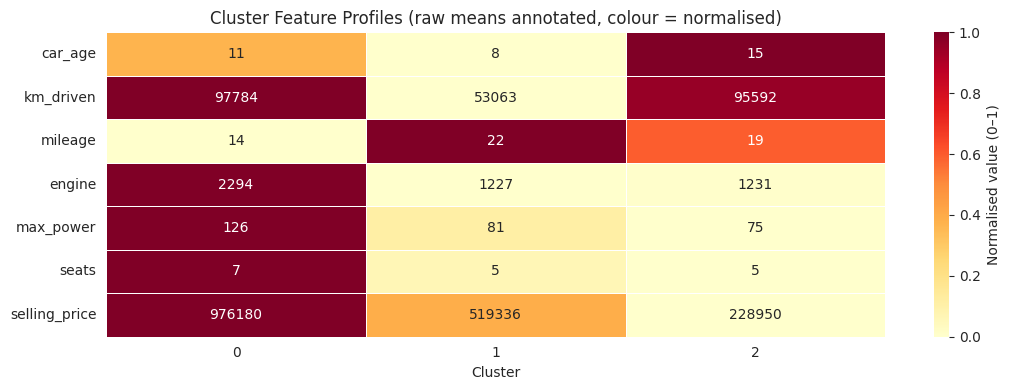

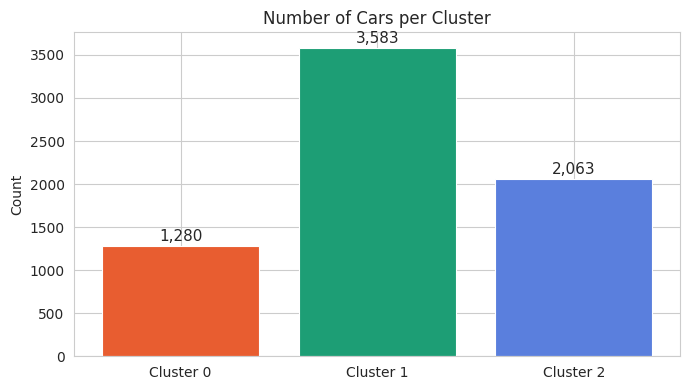

In [24]:
# Cluster Feature Profile Heatmap
numeric_features = ['car_age', 'km_driven', 'mileage', 'engine',
                     'max_power', 'seats', 'selling_price']

cluster_profile = df.groupby('cluster')[numeric_features].mean().round(2)
print('=== Cluster Profiles (Mean Values) ===')
print(cluster_profile.to_string())

profile_norm = (cluster_profile - cluster_profile.min()) / \
               (cluster_profile.max() - cluster_profile.min())

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(profile_norm.T, annot=cluster_profile.T, fmt='.0f',
            cmap='YlOrRd', linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Normalised value (0–1)'})
ax.set_title('Cluster Feature Profiles (raw means annotated, colour = normalised)')
ax.set_xlabel('Cluster')
plt.tight_layout()
plt.show()

# Cluster size bar chart
fig, ax = plt.subplots(figsize=(7, 4))
counts_c = df['cluster'].value_counts().sort_index()
bars = ax.bar([f'Cluster {i}' for i in counts_c.index],
              counts_c.values, color=palette, edgecolor='white', linewidth=0.8)
for bar, count in zip(bars, counts_c.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            f'{count:,}', ha='center', va='bottom', fontsize=11)
ax.set_title('Number of Cars per Cluster')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## Part D: Comparison & Analysis (20 pts)

### 1. Differences Between Regression and Clustering on This Dataset

| Aspect | Linear Regression (Supervised) | K-Means Clustering (Unsupervised) |
|--------|--------------------------------|-----------------------------------|
| **Goal** | Predict a specific numerical value (selling price) | Discover natural groupings in data |
| **Labels Required** | Yes — needs `selling_price` as target | No labels required |
| **Output** | Continuous numeric prediction per car | Cluster assignment (0, 1, or 2) per car |
| **Evaluation** | MAE, MSE, RMSE, R² against known values | Elbow method / Silhouette Score |
| **Features Used** | All 10 encoded + engineered features | 6 numerical features (no target) |
| **Interpretability** | Coefficients show feature direction & magnitude | Cluster centroids reveal group characteristics |

---

### 2. Insights from the Regression Model

The Linear Regression model achieved an **R² of 0.5297**, meaning the model explains approximately 53% of the variance in car selling prices. Key insights from the coefficients:

- **max_power** and **engine** are the strongest positive predictors — higher-powered, larger-engine cars command significantly higher prices.
- **car_age** has a **negative coefficient** — older cars are priced lower, confirming expected depreciation.
- **km_driven** also carries a negative effect — higher mileage reduces resale value.
- **transmission_enc** (Automatic = 1) shows a **positive coefficient** — automatic cars are priced higher.
- **owner_enc** (more previous owners) correlates negatively with price.

The moderate R² suggests that linear regression captures the major trends but may miss non-linear relationships. A polynomial or ensemble model (e.g., Random Forest) would likely improve accuracy.

---

### 3. Insights from K-Means Clustering

The Elbow Method identified **K=3** as the optimal number of clusters. The three clusters represent distinct market segments:

| Cluster | Profile | Avg Price | Avg Age | Avg KM |
|---------|---------|-----------|---------|--------|
| **0 (Blue)** | Mid-range, relatively new, moderate mileage | ₹10.87L | 12.8 yrs | 69,540 km |
| **1 (Orange)** | High-power, moderate age, very high mileage | ₹7.78L | 9.7 yrs | 217,180 km |
| **2 (Green)** | Budget, older, high mileage, low power | ₹5.76L | 15.4 yrs | 185,814 km |

This segmentation is highly actionable for pricing strategy — Cluster 0 represents the "sweet spot" used car, Cluster 1 are high-mileage workhorses sold at a discount, and Cluster 2 are entry-level budget options.

---

### 4. Which Method is More Useful for This Dataset?

**For the primary goal (predicting car selling price): Linear Regression is more useful.**

The dataset has a well-defined target variable (`selling_price`) and labeled data, making it a supervised learning problem by nature. Regression directly answers "What price should this car sell for?" which is what buyers, sellers, and dealers need.

However, **clustering adds complementary value** — it helps dealers segment their inventory, personalize marketing, and set tier-based pricing strategies without needing labeled data. In a real-world scenario, both methods would be deployed together: regression for price estimation, clustering for inventory segmentation and market analysis.
